# Session 2: Trees, Forests, and Boosting

Run the setup cell first, then work top to bottom. Search for `TODO` to find every blank.

**How to read this notebook**

Every code cell is labeled in its title bar:
- **Run only**: setup, plots, and demos. Run the cell and move on; the code is just scaffolding, nothing to study. (These show collapsed; click the title to peek if you're curious.)
- **Edit & learn**: the cells to read, fill in, and turn knobs in. These hold the scikit-learn patterns worth taking into your own work, and every reusable line is commented.

Run the next two cells first. The one below imports the tools we'll use. Most of the functions that do the actual machine learning come from scikit-learn (`sklearn`).

In [1]:
# numpy = number crunching, matplotlib = plots. These are general tools, not ML.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# The machine learning itself comes from scikit-learn (sklearn): the tree models,
# the ensembles (forest, boosting), the train/test split, and the scoring.
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

In [2]:
#@title Run only · setup (data, plot helpers)
# Plumbing only: fixed seed, patient data, and the plot helpers. (Imports are in the cell above.)

SEED = 42

HD      = "#d62728"   # red    = heart disease (the risk we're screening for)
HEALTHY = "#2ca02c"   # green  = healthy
PURPLE  = "#7b5aa6"   # the model's decision boundary / guess
GRAY    = "#9aa0a6"   # one individual tree, or held-out
TEAL    = "#1b9e9e"   # non-classification process diagrams (matches Session 1)
CORAL   = "#ff7f50"   # non-classification line plots (matches Session 1)

def make_patient_data():
    """Two features (age, cholesterol) with a rule that needs BOTH a split on age
    and, within each age group, a split on cholesterol -- so a real depth-2 tree
    naturally roots on age and then asks a cholesterol question in each branch.
    Older patients (>55) are flagged at a lower cholesterol bar than younger
    patients: this age-adjusted framing is a teaching simplification, not a real
    diagnostic rule (see the note in the markdown above)."""
    np.random.seed(SEED)
    n = 200
    age  = np.random.uniform(30, 80, n).round(0)
    chol = np.random.uniform(150, 320, n).round(0)
    hd = np.where(age > 55, (chol > 200).astype(int), (chol > 305).astype(int))
    flip = np.random.rand(n) < 0.05          # ~5% label noise: real charts aren't this clean
    hd = hd.copy(); hd[flip] = 1 - hd[flip]
    # three anchor patients used in the comprehension check (rows 0-2)
    age[0] = 68; chol[0] = 265; hd[0] = 1   # Patient A: older, past the lower cholesterol bar
    age[1] = 45; chol[1] = 305; hd[1] = 1   # Patient B: younger, but past the higher bar
    age[2] = 40; chol[2] = 260; hd[2] = 0   # Patient C: younger, under the higher bar
    return age, chol, hd

age, chol, hd = make_patient_data()
X = np.column_stack([age, chol])   # sklearn wants a 2-D table of features
y = hd

def _style(ax, title, xlabel="age (years)", ylabel="cholesterol (mg/dL)"):
    ax.set_title(title, fontsize=13)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", alpha=0.4)

def scatter_patients(ax=None):
    if ax is None: fig, ax = plt.subplots(figsize=(6.8, 5))
    m0 = y == 0; m1 = y == 1
    ax.scatter(age[m0], chol[m0], color=HEALTHY, s=32, edgecolor="k", linewidth=0.3, label="healthy (0)")
    ax.scatter(age[m1], chol[m1], color=HD,      s=32, edgecolor="k", linewidth=0.3, label="heart disease (1)")
    _style(ax, "Patients: age vs cholesterol")
    ax.legend(); return ax

def _boundary(ax, model, grid_xy, fill=True, line_color=PURPLE, lw=2.5, fill_alpha=0.12):
    """Draw a model's decision boundary as a purple line, with a light purple
    fill on the 'heart disease' side only (data points stay red/green, drawn
    separately). Falls back to a flat tint if a shallow model predicts one
    class everywhere (e.g. a depth-1 stump), since a boundary line needs both
    classes present to be drawn."""
    aa, cc = grid_xy
    zz = model.predict(np.column_stack([aa.ravel(), cc.ravel()])).reshape(aa.shape)
    if fill:
        if len(np.unique(zz)) < 2:
            if zz.max() == 1:
                ax.contourf(aa, cc, zz, levels=[-0.5, 1.5], colors=[line_color], alpha=fill_alpha)
        else:
            ax.contourf(aa, cc, zz, levels=[-0.5, 0.5, 1.5], colors=["white", line_color], alpha=fill_alpha)
    if len(np.unique(zz)) >= 2:
        ax.contour(aa, cc, zz, levels=[0.5], colors=[line_color], linewidths=lw)

_GRID = np.meshgrid(np.linspace(28, 82, 300), np.linspace(145, 325, 300))

def plot_decision_regions(model, title="", ax=None, show_pts=True):
    """Run-only: the model's decision boundary in purple, with the real patients
    (red/green) dropped on top. Every tree carves the plane into rectangles."""
    if ax is None: fig, ax = plt.subplots(figsize=(6.8, 5))
    _boundary(ax, model, _GRID)
    if show_pts:
        m0 = y == 0; m1 = y == 1
        ax.scatter(age[m0], chol[m0], color=HEALTHY, s=26, edgecolor="k", linewidth=0.3, label="healthy (0)")
        ax.scatter(age[m1], chol[m1], color=HD,      s=26, edgecolor="k", linewidth=0.3, label="heart disease (1)")
    _style(ax, title or "Decision boundary")
    if show_pts: ax.legend(fontsize=8)
    return ax

def plot_tree_and_regions(tree):
    """Run-only: the tree diagram (left) and its boundary as a purple cut on the
    scatter (right). Each yes/no question in the tree is one cut in the plane."""
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.5, 5.4))
    plot_tree(tree, feature_names=["age", "cholesterol"], class_names=["healthy", "heart disease"],
              filled=True, rounded=True, fontsize=9, ax=axL)
    axL.set_title("The tree: a chain of yes/no questions")
    plot_decision_regions(tree, "Each question = one straight cut", ax=axR)
    fig.tight_layout(); return fig

def gini(labels):
    """Gini impurity of a bucket of 0/1 labels: 0 = pure (all one class),
    0.5 = a 50/50 mix (as mixed as it gets)."""
    labels = np.asarray(labels)
    if len(labels) == 0: return 0.0
    p = labels.mean()                 # fraction with heart disease
    return 1 - (p**2 + (1 - p)**2)

def plot_impurity_across_cuts(feature="age"):
    """Run-only: sweep every candidate threshold on one feature and plot the
    weighted-average Gini of the two buckets. The tree keeps the lowest point."""
    vals = age if feature == "age" else chol
    cuts = np.linspace(vals.min() + 2, vals.max() - 2, 150)
    wav = []
    for t in cuts:
        L = y[vals < t]; R = y[vals >= t]
        wav.append((len(L) * gini(L) + len(R) * gini(R)) / len(y))
    wav = np.array(wav); best = cuts[int(np.argmin(wav))]
    fig, ax = plt.subplots(figsize=(7.2, 4.5))
    ax.plot(cuts, wav, color=CORAL, lw=2)
    ax.axvline(best, color="k", linestyle="--", lw=1.2, label=f"lowest-impurity cut ~ {best:.0f}")
    _style(ax, f"Weighted Gini impurity for every {feature} cut",
           xlabel=f"{feature} threshold", ylabel="weighted Gini (lower = cleaner)")
    ax.legend(); return ax

def plot_depth_sweep(depths, train_acc, val_acc):
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    ax.plot(depths, train_acc, "-o", color=CORAL, label="train accuracy")
    ax.plot(depths, val_acc,   "-o", color=GRAY,  label="validation accuracy")
    _style(ax, "Train vs validation accuracy as the tree gets deeper",
           xlabel="max tree depth", ylabel="accuracy (higher is better)")
    ax.set_ylim(0.5, 1.02); ax.legend(); return ax

def plot_forest_vs_trees(X_train, y_train):
    """Run-only: several individual (deep) trees as thin gray boundary lines on
    one axes, next to the 200-tree forest's bold purple boundary. One tree is
    jagged and overconfident; averaging many trees smooths the boundary."""
    fig, ax = plt.subplots(figsize=(7.5, 5.6))
    m0 = y_train == 0; m1 = y_train == 1
    ax.scatter(X_train[m0, 0], X_train[m0, 1], color=HEALTHY, s=18, alpha=0.5)
    ax.scatter(X_train[m1, 0], X_train[m1, 1], color=HD,      s=18, alpha=0.5)
    rng = np.random.RandomState(SEED)
    for i in range(5):
        idx = rng.choice(len(X_train), len(X_train), replace=True)
        t = DecisionTreeClassifier(max_depth=None, random_state=i).fit(X_train[idx], y_train[idx])
        _boundary(ax, t, _GRID, fill=False, line_color=GRAY, lw=1.1)
    forest = RandomForestClassifier(n_estimators=200, random_state=SEED).fit(X_train, y_train)
    _boundary(ax, forest, _GRID, fill=True, line_color=PURPLE, lw=3, fill_alpha=0.10)
    from matplotlib.lines import Line2D
    handles = [Line2D([0], [0], color=GRAY, lw=1.1, label="one tree (thin gray)"),
               Line2D([0], [0], color=PURPLE, lw=3, label="forest of 200 (bold purple)")]
    _style(ax, "One tree is jagged; averaging many trees smooths the boundary")
    ax.legend(handles=handles, fontsize=9)
    fig.tight_layout(); return fig

def plot_bagging_diagram(n_show=20, n_trees=4):
    """Run-only: how bagging resamples patients. Each row is one tree's draw of
    the same 20 patients, WITH replacement: some appear twice (coral), some not
    at all (gray = out-of-bag, free to test on)."""
    from matplotlib.patches import Patch
    rng = np.random.RandomState(SEED)
    fig, ax = plt.subplots(figsize=(9, 0.7 * n_trees + 1.1))
    for t in range(n_trees):
        counts = np.bincount(rng.choice(n_show, n_show, replace=True), minlength=n_show)
        for p in range(n_show):
            color = GRAY if counts[p] == 0 else (TEAL if counts[p] == 1 else CORAL)
            ax.add_patch(plt.Rectangle((p, t), 1, 0.8, color=color, ec="white"))
    ax.set_xlim(0, n_show); ax.set_ylim(0, n_trees)
    ax.set_yticks(np.arange(n_trees) + 0.4); ax.set_yticklabels([f"tree {i+1}" for i in range(n_trees)])
    ax.set_xticks([]); ax.invert_yaxis()
    ax.set_title("Bagging: each tree draws its own patients (with replacement)")
    ax.legend(handles=[Patch(color=GRAY, label="never drawn (out-of-bag)"),
                       Patch(color=TEAL, label="drawn once"),
                       Patch(color=CORAL, label="drawn 2+ times")],
              loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=3, fontsize=9, frameon=False)
    fig.tight_layout(); return fig

def make_patient_features():
    """The forest's feature panel: six real cardiovascular risk factors (age,
    cholesterol, blood pressure, smoking, diabetes, family history), grounded
    in real ASCVD/Framingham risk factors. Unlike Session 1's house table,
    there are no invented junk columns here -- all six plausibly matter, so
    this demo is about SEEING bagging + feature shuffling at work, not about
    spotting noise."""
    np.random.seed(SEED)
    n = 500
    age   = np.random.uniform(30, 80, n)
    chol  = np.random.uniform(150, 320, n)
    bp    = np.random.uniform(90, 180, n)      # systolic blood pressure
    smoke = np.random.binomial(1, 0.25, n)
    diabetes = np.random.binomial(1, 0.15, n)
    famhist  = np.random.binomial(1, 0.20, n)  # family history of heart disease
    score = (0.05*(age-55) + 0.02*(chol-235) + 0.04*(bp-130)
             + 1.1*smoke + 0.9*diabetes + 0.7*famhist)
    prob = 1 / (1 + np.exp(-score))
    hd = (np.random.rand(n) < prob).astype(int)
    Xf = np.column_stack([age, chol, bp, smoke, diabetes, famhist])
    return Xf, hd

PATIENT_FEATURES = ["age", "cholesterol", "blood pressure", "smoking", "diabetes", "family history"]
X_pf, y_pf = make_patient_features()

def plot_feature_shuffling_table(X_train, y_train, n_trees=8):
    """Run-only: rows are bagged trees (each on its own resample); columns are
    the six features. Each tree here is a depth-1 stump restricted to ONE
    candidate feature at its split (max_features=1), so the marked cell shows
    exactly which feature that tree's random draw handed it -- the
    columns-are-feature-shuffling picture, spread cleanly across all six."""
    forest = RandomForestClassifier(n_estimators=n_trees, max_depth=1, max_features=1,
                                    bootstrap=True, random_state=SEED).fit(X_train, y_train)
    used = []
    for est in forest.estimators_:
        feats = sorted(set(int(f) for f in est.tree_.feature if f >= 0))
        used.append(feats)
    fig, ax = plt.subplots(figsize=(9, 0.6*n_trees + 1.3))
    for i, feats in enumerate(used):
        for j in range(len(PATIENT_FEATURES)):
            color = PURPLE if j in feats else "white"
            ax.add_patch(plt.Rectangle((j, i), 1, 0.85, facecolor=color, edgecolor="k", linewidth=0.6, alpha=0.75 if j in feats else 1.0))
    ax.set_xlim(0, len(PATIENT_FEATURES)); ax.set_ylim(0, n_trees)
    ax.set_xticks(np.arange(len(PATIENT_FEATURES)) + 0.5)
    ax.set_xticklabels(PATIENT_FEATURES, rotation=30, ha="right")
    ax.set_yticks(np.arange(n_trees) + 0.42); ax.set_yticklabels([f"tree {i+1}" for i in range(n_trees)])
    ax.invert_yaxis()
    ax.set_title("Rows: each tree's own resample (bagging).  Columns: the one\nfeature its random draw let it split on (feature shuffling).", fontsize=11)
    fig.tight_layout(); return fig

def plot_feature_importance(importances, names):
    """One labeled bar per feature: how much it helped the forest's splits.
    All six are real risk factors, so this ranks them, it doesn't sort signal
    from noise."""
    order = np.argsort(importances)[::-1]
    fig, ax = plt.subplots(figsize=(8, 4.6))
    ax.bar(range(len(importances)), np.array(importances)[order], color=TEAL, edgecolor="k", linewidth=0.4)
    ax.set_xticks(range(len(importances))); ax.set_xticklabels(np.array(names)[order], rotation=30, ha="right")
    ax.set_title("How much each risk factor helped the forest's splits")
    ax.set_ylabel("importance (higher = more useful)")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    fig.tight_layout(); return fig

def plot_boosting_rounds(boost, X_tr, y_tr, X_va, y_va):
    """Run-only: staged_predict replays the ensemble after each added tree, so we
    can watch the leftover error fall round by round on train and validation."""
    tr_err = [1 - accuracy_score(y_tr, p) for p in boost.staged_predict(X_tr)]
    va_err = [1 - accuracy_score(y_va, p) for p in boost.staged_predict(X_va)]
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    ax.plot(range(1, len(tr_err)+1), tr_err, color=CORAL, lw=2, label="train error")
    ax.plot(range(1, len(va_err)+1), va_err, color=GRAY,  lw=2, label="validation error")
    _style(ax, "Each new tree fixes a little more of the leftover error",
           xlabel="number of trees (boosting rounds)", ylabel="error (lower is better)")
    ax.legend(); return ax

def plot_forest_vs_boosting(X_tr, y_tr, X_va, y_va):
    """Run-only: the two boundaries side by side (both purple, since both are
    'the model's guess'), plus validation accuracy vs number of trees. The
    forest plateaus; boosting climbs then can dip if over-grown."""
    fig = plt.figure(figsize=(15.5, 4.6)); gs = gridspec.GridSpec(1, 3, wspace=0.3)
    f = RandomForestClassifier(n_estimators=200, random_state=SEED).fit(X_tr, y_tr)
    b = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=2,
                                   random_state=SEED).fit(X_tr, y_tr)
    ax0 = fig.add_subplot(gs[0]); plot_decision_regions(f, "Random forest", ax=ax0, show_pts=False)
    ax1 = fig.add_subplot(gs[1]); plot_decision_regions(b, "Gradient boosting", ax=ax1, show_pts=False)
    ax2 = fig.add_subplot(gs[2])
    grid_n = list(range(1, 50, 3)) + list(range(50, 201, 15))
    f_acc = [accuracy_score(y_va, RandomForestClassifier(n_estimators=k, random_state=SEED)
                            .fit(X_tr, y_tr).predict(X_va)) for k in grid_n]
    b_acc = [accuracy_score(y_va, p) for p in b.staged_predict(X_va)]
    ax2.plot(grid_n, f_acc, color=TEAL, lw=2, label="forest")
    ax2.plot(range(1, len(b_acc)+1), b_acc, color=CORAL, lw=2, label="boosting")
    _style(ax2, "Validation accuracy vs number of trees",
           xlabel="number of trees", ylabel="validation accuracy")
    ax2.legend(); fig.tight_layout(); return fig

print("Setup complete")
print(f"{y.sum()} of {len(y)} patients have heart disease.")
print("First 5 rows (age, cholesterol, heart disease):")
for i in range(5):
    print(f"  age={age[i]:>4.0f}  cholesterol={chol[i]:>5.0f}  heart_disease={y[i]}")

Setup complete
76 of 200 patients have heart disease.
First 5 rows (age, cholesterol, heart disease):
  age=  68  cholesterol=  265  heart_disease=1
  age=  45  cholesterol=  305  heart_disease=1
  age=  40  cholesterol=  260  heart_disease=0
  age=  60  cholesterol=  303  heart_disease=1
  age=  38  cholesterol=  253  heart_disease=0


## 1 · Meet the data

Each patient has an **age** and a **cholesterol** level, and we've labeled them **heart disease** or **healthy**. This is a simplified stand-in for risk screening: real cardiovascular risk depends on many factors, and no single cutoff diagnoses anyone. Here we're building intuition for how a model finds a rule, not a real clinical tool.

The rule this data follows: older patients (over 55) get flagged at a *lower* cholesterol level than younger patients do. That's a simplified stand-in for age-adjusted risk. (Real guidelines classify cholesterol as desirable, borderline, or high, with no official category above 240 mg/dL; the numbers here are a teaching simplification, not diagnostic cutoffs.) A single straight line can't express that rule cleanly, since the cholesterol bar changes depending on age. That's exactly the kind of pattern a tree is good at.

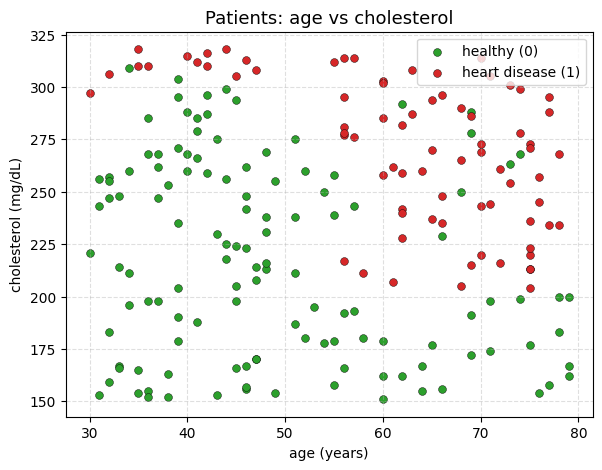

76 of 200 patients have heart disease.


In [3]:
#@title Run only · see the raw data
scatter_patients()
plt.show()
print(f'{y.sum()} of {len(y)} patients have heart disease.')

## 2 · Fit a decision tree

You already use decision trees every day: *is the store open, do I already have food, do I need to cook soon.* Each yes/no answer sends you down a path until you land on a decision. A decision tree model works the same way: a chain of yes/no questions that ends in a prediction. Its advantage is that you can read it and see exactly why it decided.

`.fit(X, y)` learns the questions; `.predict(X)` runs a patient down the branches. Same pattern as every sklearn model.

> Functions you'll use
> - `DecisionTreeClassifier(max_depth=...)`: make an unfitted tree (max_depth caps how many questions deep it can go)
> - `model.fit(X, y)`: learn the questions from data
> - `model.predict(X)`: guess a label for each patient

Hint: the blanks are just the function names, the same `fit` / `predict` pair from Session 1.

In [4]:
#@title Edit & learn · fit a decision tree (the core sklearn pattern)
tree = DecisionTreeClassifier(max_depth=2, random_state=SEED)  # an (unfitted) depth-2 tree
tree.fit(X, y)             # fit = learn the yes/no questions from the data
guesses = tree.predict(X)  # predict = run each patient down the branches

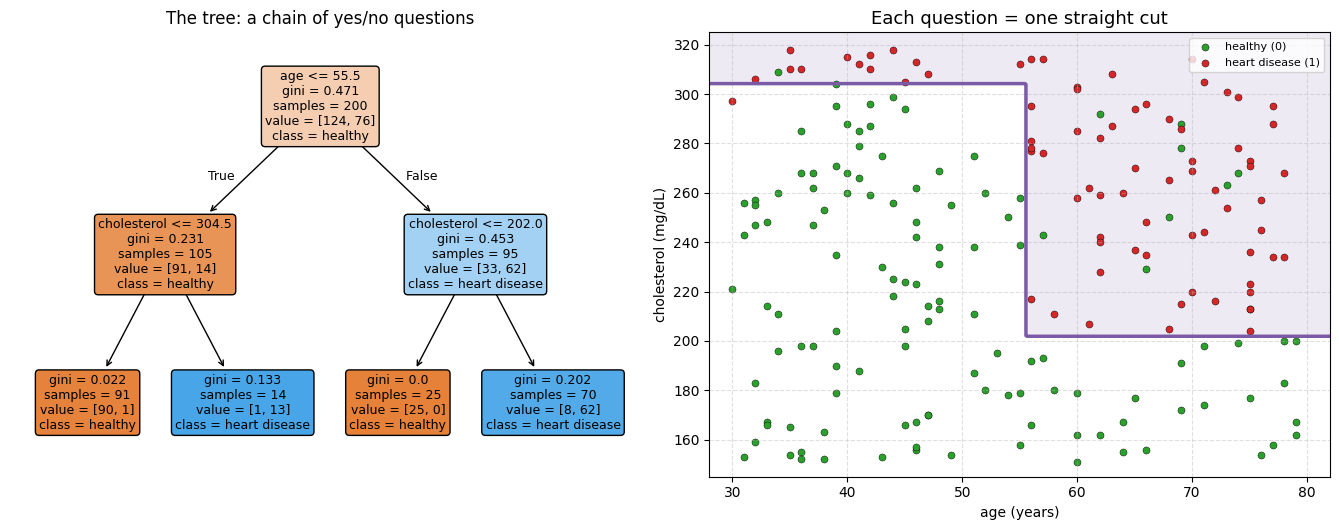

training accuracy = 0.95


In [5]:
#@title Run only · the tree and its cuts
plot_tree_and_regions(tree)
plt.show()
print(f'training accuracy = {accuracy_score(y, tree.predict(X)):.2f}')

**Check your understanding**

Read the tree above and predict each patient by hand, then check against the model:
- Patient A, age 68, cholesterol 265
- Patient B, age 45, cholesterol 305
- Patient C, age 40, cholesterol 260

**Answer:** A is heart disease (age is past the ~55 cut, and cholesterol clears the lower bar used for older patients). B is heart disease (young, but cholesterol clears the higher bar used for younger patients). C is healthy (young, and under that higher bar). Notice the tree asks about age first, then asks a cholesterol question, but a *different* cholesterol question depending on which age branch you're in. That's the rule the data was built on.

## 2b · How a split is chosen: Gini impurity

The tree isn't handed its questions, it finds them. It tries every feature and every threshold and keeps the cut that best separates heart disease from healthy. How does it score a cut? With a loss function called **Gini impurity**.

Gini measures how mixed a bucket is: **0 = pure** (all one class), **0.5 = a 50/50 mix** (as mixed as it gets). A cut makes two buckets; the tree takes the size-weighted average of their impurities and keeps the cut that makes that number smallest. You never compute this by hand, you just need the intuition: **lower Gini = cleaner split**.

The tree's first question above was on age, so let's see why: sweep every candidate age cut and watch the impurity.

> Functions you'll use
> - `gini(labels)`: provided helper, the impurity of one bucket of 0/1 labels

Hint: split the labels into the two buckets, then measure each bucket's impurity with `gini(...)`.

In [6]:
#@title Edit & learn · try a cut and measure its purity
threshold = 55            # knob: an age cut. try 40, 55, 65
left  = y[age <  threshold]   # patients below the cut
right = y[age >= threshold]   # patients at or above the cut

# weighted average of the two buckets' Gini impurity (lower = cleaner split)
wavg = (len(left) * gini(left) + len(right) * gini(right)) / len(y)
print(f'cut at age = {threshold}')
print(f'  left bucket  gini = {gini(left):.3f}  ({len(left)} patients)')
print(f'  right bucket gini = {gini(right):.3f}  ({len(right)} patients)')
print(f'  weighted-average impurity = {wavg:.3f}   (lower is a cleaner split)')

cut at age = 55
  left bucket  gini = 0.226  (100 patients)
  right bucket gini = 0.466  (100 patients)
  weighted-average impurity = 0.346   (lower is a cleaner split)


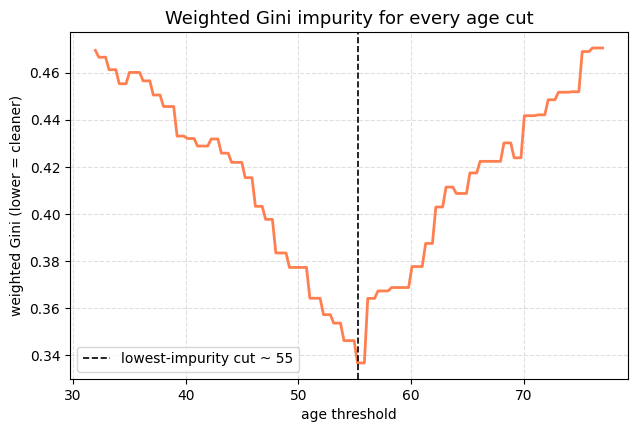

In [7]:
#@title Run only · impurity across every candidate cut
plot_impurity_across_cuts('age')
plt.show()
# the tree would pick the threshold at the lowest point of this curve -- close to what it actually chose.

**Check your understanding**

One cut leaves the left bucket 95% healthy / 5% heart disease, and the right bucket a 55% / 45% mix. Which bucket has the higher Gini impurity, and what does that tell the tree?

**Answer:** The right bucket (the near-50/50 mix) has the higher impurity, it's much more mixed. The left bucket is almost pure, so its Gini is low. A good cut is one where both buckets come out as pure as possible, so the tree keeps looking for a way to further split that messy right bucket.

## 3 · Overfitting: growing a tree too deep

A tree keeps asking questions until its buckets are pure. If you let it, it will keep splitting until every patient sits in its own tiny box, including the noisy, mislabeled ones. That's overfitting: it has memorized the training patients instead of learning the general rule. Same story as Session 1's high-degree polynomial, told with boxes instead of wiggles.

The knob is `max_depth`, how many questions deep the tree may go. Watch the decision boundary: shallow trees draw a simple two-step cut; deep trees fracture into little islands around individual points.

> Functions you'll use
> - `accuracy_score(y_true, y_pred)`: fraction correct; higher is better

Hint: score the tree twice, once on the data it trained on, once on the held-out data it never saw.

In [8]:
#@title Edit & learn · turn the depth knob
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=SEED)

max_depth = 3   # knob: try 1 (a stump), 3, and None (grow until pure)
tree = DecisionTreeClassifier(max_depth=max_depth, random_state=SEED).fit(X_train, y_train)

train_acc = accuracy_score(y_train, tree.predict(X_train))  # graded on data it learned from
val_acc   = accuracy_score(y_val,   tree.predict(X_val))    # graded on held-out data it never saw
print(f'max_depth = {max_depth}')
print(f'  train accuracy      = {train_acc:.2f}')
print(f'  validation accuracy = {val_acc:.2f}')
# expected: deep trees push train toward 1.00 while validation stalls or falls -- that gap is overfitting.

max_depth = 3
  train accuracy      = 0.96
  validation accuracy = 0.92


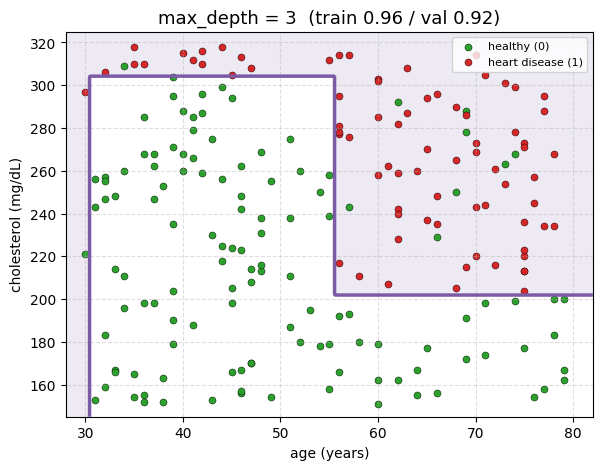

In [9]:
#@title Run only · the boundary at this depth
plot_decision_regions(tree, f'max_depth = {max_depth}  (train {train_acc:.2f} / val {val_acc:.2f})')
plt.show()
# shallow = a simple two-step boundary; deep = little boxes drawn around individual (often noisy) patients.

**Check your understanding**

A tree with 200 splits for 200 patients reaches 100% training accuracy. Should we trust it on a new patient? Why or why not?

**Answer:** No, it's almost certainly overfitting. With one split per patient it has drawn a private box around each training point (noise and all), so a perfect training score tells us nothing about new patients. The only honest check is accuracy on held-out data it never saw.

## 3b · Watch the gap open

One fit gave one picture. Now sweep the depth from 1 to 12 and plot train vs validation accuracy together, the tree-shaped twin of Session 1's polynomial-degree sweep. Training accuracy marches toward 1.0; validation accuracy peaks at some modest depth and then sags as the tree starts memorizing. The gap between the curves is overfitting.

Before you run it, predict: at depth 12, is the training accuracy high or low? Is the validation accuracy high or low? Roughly where do the two curves start pulling apart?

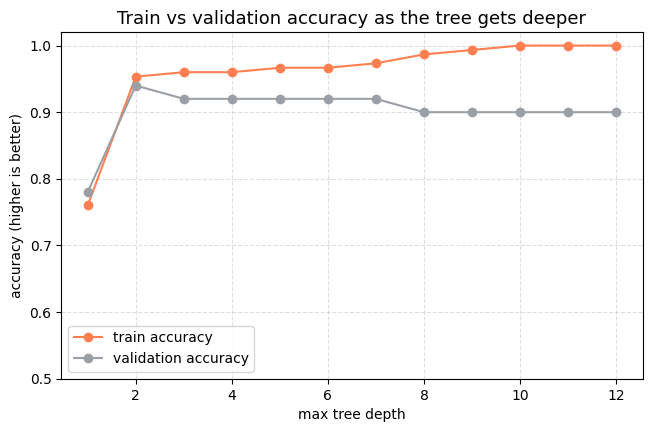

In [10]:
#@title Edit & learn · the depth sweep
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=SEED)

depths = range(1, 13)
train_acc, val_acc = [], []
for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=SEED).fit(X_train, y_train)
    # train score: measured on the data the tree learned from
    train_acc.append(accuracy_score(y_train, tree.predict(X_train)))
    # validation score: measured on data the tree never saw
    val_acc.append(accuracy_score(y_val, tree.predict(X_val)))

plot_depth_sweep(list(depths), train_acc, val_acc)
plt.show()

In [11]:
#@title Run only · what the sweep shows
# depth 1 (too shallow): a single stumpy cut -- underfit / high bias.
# a modest depth (~2-3): validation accuracy peaks -- the sweet spot.
# deep (6-12): train accuracy hits 1.00 while validation sags -- overfit / high variance.
print('See the comments in this cell for what each region of the sweep shows.')

See the comments in this cell for what each region of the sweep shows.


## 4 · Random forests

One tree is easy to overfit and easy to fool. The fix: don't trust one tree, grow many and let them vote. For a new patient each tree says heart disease or healthy, and we take the majority. One tree's weird mistakes get outvoted by the rest, and the signal they share survives.

> Functions you'll use
> - `RandomForestClassifier(n_estimators=...)`: a forest of that many trees; `.fit` / `.predict` as usual

Hint: the blank is just the model name, the classifier that grows many trees and votes.

In [12]:
#@title Edit & learn · grow a forest and vote
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=SEED)

forest = RandomForestClassifier(n_estimators=200, random_state=SEED).fit(X_train, y_train)
val_acc = accuracy_score(y_val, forest.predict(X_val))
print(f'forest of 200 trees -> validation accuracy = {val_acc:.2f}')

forest of 200 trees -> validation accuracy = 0.92


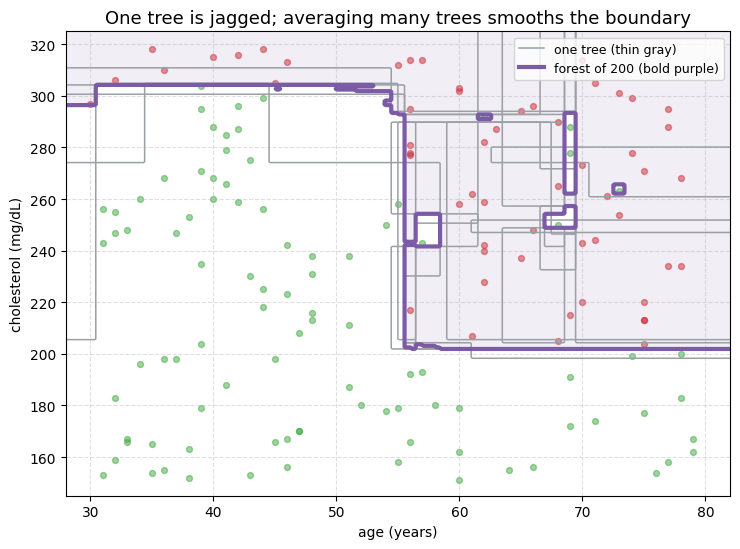

In [13]:
#@title Run only · one jagged tree vs the smooth forest
plot_forest_vs_trees(X_train, y_train)
plt.show()

## 4b · What makes the trees differ: bagging

A forest only helps if its trees actually disagree. The main trick: **bagging** (bootstrap aggregating). Each tree is trained on its own random resample of the patients, drawn *with replacement*: some patients appear twice, some not at all. Different data means a different tree.

**Bonus, out-of-bag (OOB) score:** since each tree skips some patients, you can test each patient on just the trees that didn't train on it. That gives a free accuracy estimate with no separate test set (`oob_score=True` -> `forest.oob_score_`).

(There's a second trick, feature shuffling, that only makes sense once a tree has more than two features to choose from; we'll pick that up in the next section with a wider patient panel.)

> Functions you'll use
> - `RandomForestClassifier(bootstrap=, oob_score=)`
> - `forest.oob_score_`: the out-of-bag accuracy estimate

Hint: turn `bootstrap` off and the trees all see identical data, watch the forest collapse to one opinion.

In [14]:
#@title Edit & learn · turn bagging on and off
bootstrap = True     # knob: True = each tree gets its own resample; False = every tree sees the same data

# max_features=None turns OFF feature shuffling here, so bagging is the ONLY source of
# randomness (feature shuffling is the next section). That's what lets bootstrap=False
# collapse every tree to the same shape.
forest = RandomForestClassifier(
    n_estimators=200, bootstrap=bootstrap, oob_score=bootstrap,
    max_features=None, random_state=SEED).fit(X_train, y_train)

oob = forest.oob_score_ if bootstrap else float('nan')   # the free out-of-bag accuracy estimate
val_acc = accuracy_score(y_val, forest.predict(X_val))
print(f'bootstrap={bootstrap}')
print(f'  out-of-bag accuracy  = {oob:.2f}   (free estimate, no separate test set)')
print(f'  validation accuracy  = {val_acc:.2f}')
# expected: bootstrap=False -> identical trees, no OOB estimate; bootstrap=True -> best of the lot.

bootstrap=True
  out-of-bag accuracy  = 0.92   (free estimate, no separate test set)
  validation accuracy  = 0.92


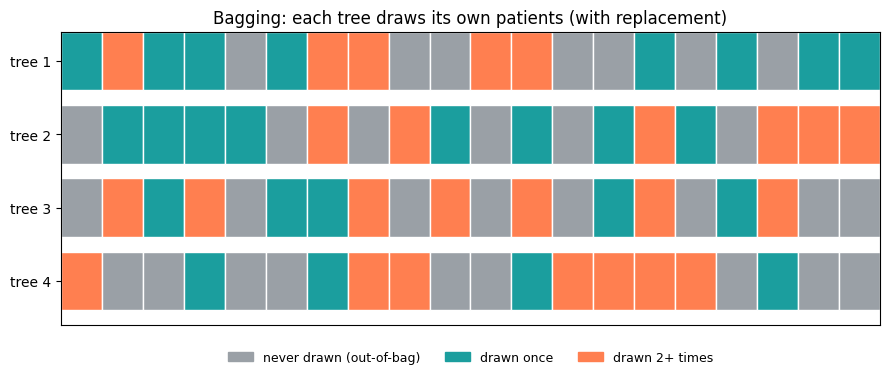

In [15]:
#@title Run only · bagging in a picture
plot_bagging_diagram()
plt.show()

**Check your understanding**

If you train 100 trees on the exact same data with no randomness, what does the forest predict versus one tree, and why is that useless?

**Answer:** They predict the same thing. With no randomness all 100 trees are identical, so they all vote the same way, averaging 100 copies of one opinion is still just that one opinion. You need the trees to differ.

## 5 · More features: feature shuffling and importance

Bagging alone has a limit: if one feature is unusually strong, most trees will still split on it first, so the trees stay more similar than you'd like. The fix is **feature shuffling**: at each split, a tree may only choose from a random handful of features, not all of them. Sometimes the strongest feature isn't even on the menu, so the tree has to learn from something else.

This needs more than two features to be meaningful, so here's a wider patient panel: **age, cholesterol, blood pressure, smoking, diabetes, and family history**, six real cardiovascular risk factors. Unlike Session 1's house table, there's no invented junk column here; all six plausibly matter. So this section isn't about spotting noise, it's about seeing bagging and feature shuffling produce different trees, and then reading off which factors the forest leaned on most. One caveat about that readout: impurity-based importance tends to favor continuous features with many possible split points (like age or blood pressure) over yes/no features (like smoking), so treat it as "how useful was this feature to the trees," not a verdict on real-world medical importance.

The table below fits eight shallow (one-question) trees, each restricted to a *single* candidate feature per split (an extreme version of feature shuffling, chosen so the effect is easy to see; in practice you'd allow a small handful, like the square root of the total feature count). Each row is one tree's own bootstrap resample (bagging); the shaded column is the one feature its random draw let it use. Different trees land on different features.

> Functions you'll use
> - `RandomForestClassifier(...).feature_importances_`: one importance value per feature

Hint: the blank is the attribute that holds those importances.

validation accuracy = 0.76


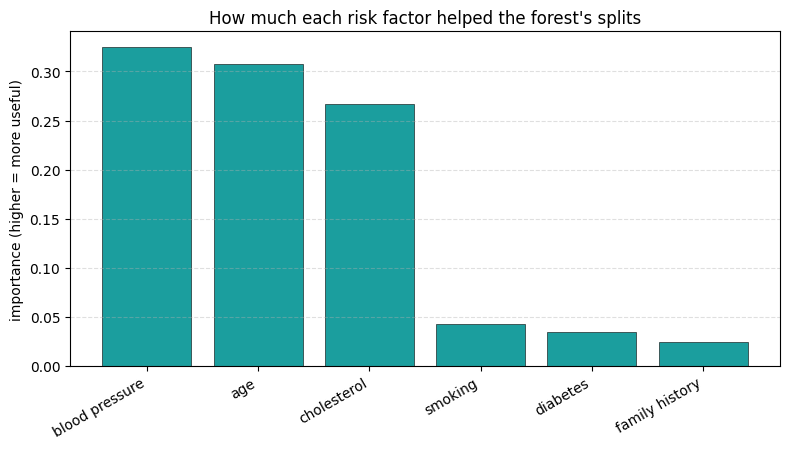

In [16]:
#@title Edit & learn · read the forest's feature importances
Xtr, Xva, ytr, yva = train_test_split(X_pf, y_pf, test_size=0.25, random_state=SEED)

forest = RandomForestClassifier(n_estimators=300, random_state=SEED).fit(Xtr, ytr)
importances = forest.feature_importances_   # how much each feature helped the splits
val_acc = accuracy_score(yva, forest.predict(Xva))
print(f'validation accuracy = {val_acc:.2f}')

plot_feature_importance(importances, PATIENT_FEATURES)   # provided chart helper
plt.show()

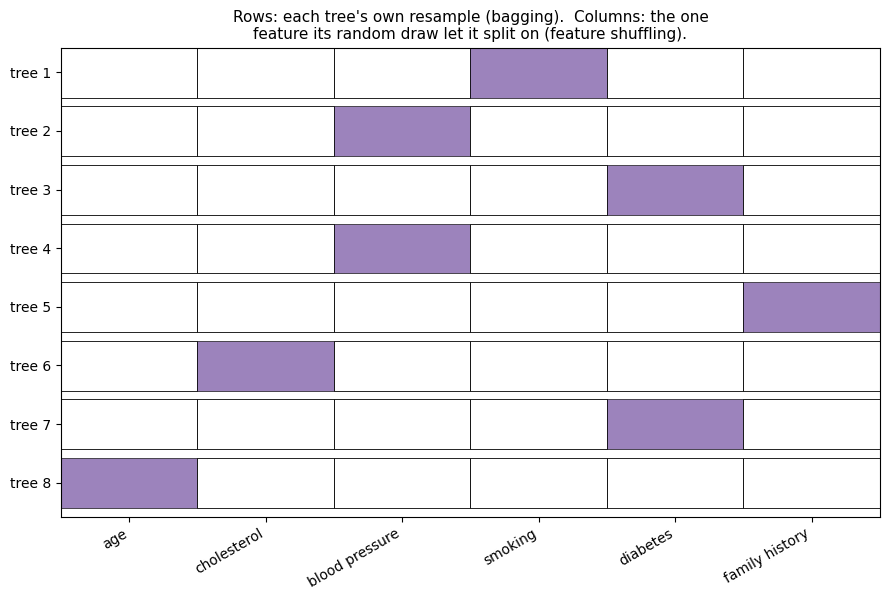

In [17]:
#@title Run only · feature shuffling in a table
plot_feature_shuffling_table(Xtr, ytr)
plt.show()
# each row is a different tree's resample; the shaded column is the one feature it was allowed to split on.

**Check your understanding**

Each row in the table above is a single-feature stump that gets only modest accuracy on its own. How can averaging many such simple, one-feature trees produce a much stronger combined prediction?

**Answer:** Each stump captures a small, real piece of the pattern (one risk factor's effect), and each stump's mistakes are different because it saw a different feature and a different resample. Averaging cancels out the mistakes that don't agree while keeping the signal that most trees pick up on, so the vote ends up stronger than any single simple tree.

## 6 · Gradient boosting

A forest builds all its trees independently and averages them. Gradient boosting takes the opposite approach: it builds many small trees in sequence, and each new tree is trained to fix the mistakes the previous trees are still making. Their corrections add up, and the error drops a little more every round.

The recipe: train a small tree, measure what it still gets wrong (the residual error), train the next tree to predict that error, add it in, repeat. Instead of one complex tree, you get many simple trees that each fix what's still wrong.

> Functions you'll use
> - `GradientBoostingClassifier(n_estimators=, learning_rate=, max_depth=)`: sequential small trees

Hint: the blank is just the model name, the classifier that boosts.

In [18]:
#@title Edit & learn · boost, round by round
Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.25, random_state=SEED)

boost = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=2,
                                   random_state=SEED).fit(Xtr, ytr)
val_acc = accuracy_score(yva, boost.predict(Xva))
print(f'gradient boosting -> validation accuracy = {val_acc:.2f}')

gradient boosting -> validation accuracy = 0.88


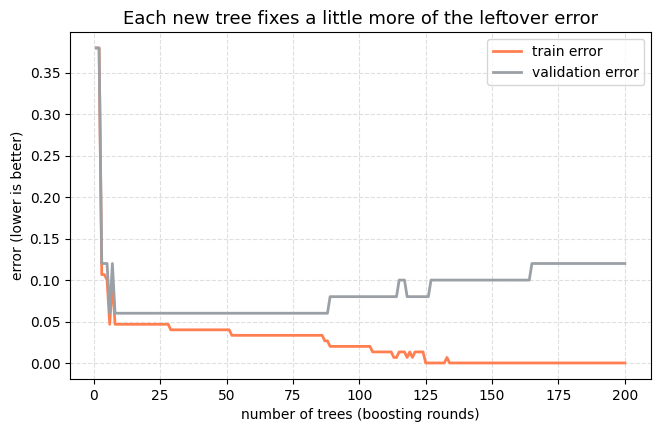

In [19]:
#@title Run only · the error shrinking each round
plot_boosting_rounds(boost, Xtr, ytr, Xva, yva)
plt.show()
# each added tree chips a little more off the leftover error; train keeps falling, validation levels off.

## 6b · Forests vs boosting

Both combine trees, but in opposite ways:

- **Forest**: trees built independently, all at once, then averaged / voted. Order doesn't matter. It mainly smooths out noise, and adding more trees rarely hurts.
- **Boosting**: trees built in a chain, each fixing the last. Order is everything. It chases down the remaining error, so it can be more accurate, but adding too many trees can overfit, so it needs tuning (number of trees, learning rate, tree depth).

Rule of thumb: reach for a forest when you want a strong, low-fuss baseline; reach for boosting when you want to squeeze out extra accuracy and are willing to tune.

/sessions/focused-blissful-davinci/tmp/ipykernel_8/343056522.py:263: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  ax2.legend(); fig.tight_layout(); return fig


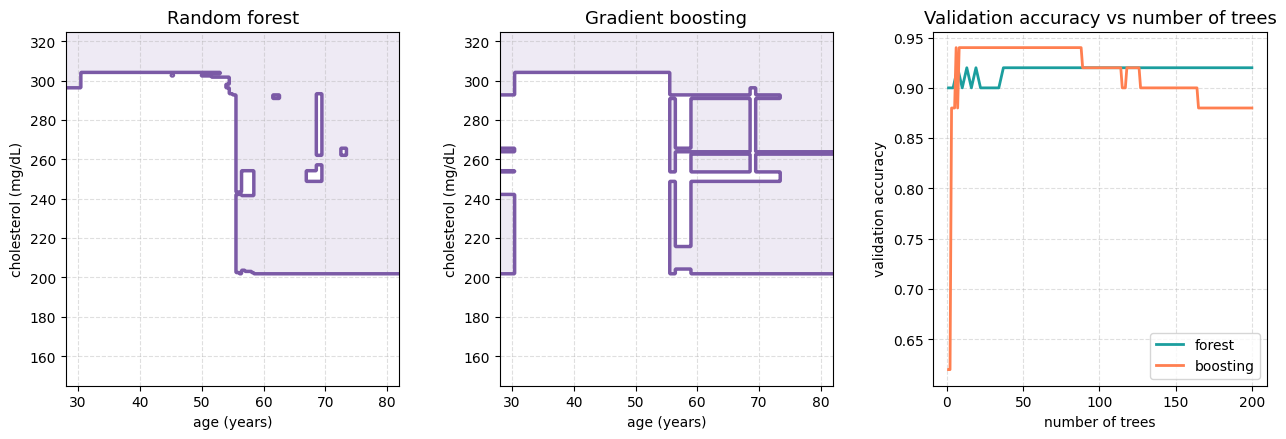

In [20]:
#@title Run only · two boundaries, and accuracy vs number of trees
plot_forest_vs_boosting(Xtr, ytr, Xva, yva)
plt.show()
# forest accuracy plateaus and stays flat; boosting climbs then can dip if you add too many trees.

**Check your understanding**

You shuffle the order in which the trees were built. Which model's prediction changes, the forest or the boosted model, and why?

**Answer:** The boosted model changes. Each of its trees was trained to fix the specific errors left by the ones before it, so the sequence is part of the model, reorder the trees and every correction lands on the wrong leftover. The forest is unaffected: its trees are built independently and then averaged, so their order is irrelevant.

## Use it in your own work

Everything above, distilled to the four steps you'll reuse on any dataset: split, fit, predict, score. Copy this cell and swap in your own features and target.

In [21]:
#@title Edit & learn · the whole workflow to copy into your own work
# Replace X and y below with your own features and labels.
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. split FIRST, so the held-out set stays untouched
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=42)   # random_state = reproducible split

# 2. create and fit a model on the training data only
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# 3. predict on new / held-out data
preds = model.predict(X_val)

# 4. score honestly on data the model never saw
print('accuracy on held-out data:', accuracy_score(y_val, preds))

accuracy on held-out data: 0.92


## 7 · Recap

- **decision tree**: a chain of yes/no cuts ending in a prediction; you can read it and see exactly why it decided.
- **Gini impurity**: how mixed a bucket is (0 = pure, 0.5 = 50/50); the tree keeps the cut that lowers it most.
- **overfitting a tree**: grow it too deep and it boxes in every patient, noise included: high train accuracy, collapsing validation accuracy.
- **random forest**: many different trees vote; **bagging** (resampling) and **feature shuffling** make them differ, and the **out-of-bag** score is a free accuracy estimate.
- **feature importance**: the forest tells you which risk factors it leaned on most.
- **gradient boosting**: small trees in a chain, each fixing the last; powerful but needs tuning.
- **forest vs boosting**: a forest smooths noise (order-free); boosting chases error (order is everything).

Next session: putting these models to work and grading them properly.

## Appendix: function cheat sheet

Build a model
- `DecisionTreeClassifier(max_depth=...)`: a single tree of yes/no questions
- `RandomForestClassifier(n_estimators=, max_features=, bootstrap=, oob_score=)`: many trees that vote
- `GradientBoostingClassifier(n_estimators=, learning_rate=, max_depth=)`: small trees in a chain, each fixing the last

Fit & predict
- `model.fit(X, y)`: learn from data
- `model.predict(X)`: guess a label (0/1) for each row
- `model.predict_proba(X)`: class probabilities; column `[:, 1]` is P(heart disease)

Split & score
- `train_test_split(X, y, test_size=, random_state=)` returns `X_train, X_val, y_train, y_val`
- `accuracy_score(y_true, y_pred)`: fraction correct; higher is better
- `cross_val_score(model, X, y, cv=K)`: runs the K-fold loop; average the K scores

Inspect
- `forest.feature_importances_`: how much each feature helped the splits
- `forest.oob_score_`: the out-of-bag accuracy estimate (needs `oob_score=True`)
- `plot_tree(model, ...)`: draw the tree

Knobs that control complexity
- deeper tree (`max_depth`) = more complex, more prone to overfit
- more trees (`n_estimators`) = smoother forest / more corrective boosting
- higher `learning_rate` = bigger boosting steps (faster, but easier to overshoot)